<h1><center>Uke 4 - Når målingene ikke passer</center></h1>

<h3><center>IMAG3011 – Matematikk for ingeniørfag 3A</h3>

<p><center><strong>Bjørn Ivar Thorsen Høie</strong></center></p>

<p><center>NTNU Gjøvik</center></p>

<p><center>September 2026</center></p>

<br>

<p><center>Oppdraget er å begrunne en metode og en tilpasning med egne forsøk</center></p>

## Metoder som trengs for å løse prosjektet

In [1]:
# MGS beregner hver komponent på den oppdaterte resten.
# Sammenlign med CGS på identiske matriser, ikke på ulike datasett.
def modified_gram_schmidt(A, tolerance=None):
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    if not np.isfinite(A).all():
        raise ValueError("A må bare inneholde endelige tall")
    # Grensen skaleres med maskinpresisjon, dimensjoner og matrisens størrelse.
    if tolerance is None:
        tolerance = np.finfo(float).eps * max(m, n) * np.linalg.norm(A, "fro")
    for j in range(n):
        # copy lar oss oppdatere resten uten å endre den opprinnelige matrisen.
        v = A[:, j].copy()
        for i in range(j):
            # MGS: Beregn på resten etter forrige subtraksjon, ikke på A[:, j].
            R[i, j] = Q[:, i] @ v
            v = v - R[i, j]*Q[:, i]
        R[j, j] = np.linalg.norm(v)
        if not np.isfinite(R[j, j]):
            raise np.linalg.LinAlgError("Ikke-endelig rest under faktoriseringen")
        # En for liten rest gir ingen pålitelig ny retning; stopp før normalisering.
        if R[j, j] <= tolerance:
            raise np.linalg.LinAlgError(
                f"Kolonne {j+1} gir ingen pålitelig ny retning"
            )
        Q[:, j] = v/R[j, j]
    return Q, R

In [2]:
# Én løkkeomgang behandler én opprinnelig kolonne a_j.
# Q lagrer enhetsvektorene; kolonne j i R lagrer regnskapet for a_j.
def classical_gram_schmidt(A):
    """Pedagogisk implementasjon uten rangkontroll."""
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        # CGS: Alle indreproduktene bruker den opprinnelige kolonnen A[:, j].
        coefficients = Q[:, :j].T @ A[:, j]
        # Lagre tallene før resten normaliseres; de trengs for å gjenskape a_j.
        R[:j, j] = coefficients
        # Summen av tidligere vektorbidrag trekkes fra på én gang.
        v = A[:, j] - Q[:, :j] @ coefficients
        R[j, j] = np.linalg.norm(v)
        # Denne naive varianten deler også når lengden er null; neste forsøk viser følgen.
        Q[:, j] = v / R[j, j]
    return Q, R

In [3]:
def qr_solution(A, b, qr_method=modified_gram_schmidt):
    """Minste-kvadraters løsning fra en tynn QR-faktorisering."""
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)

    if A.ndim != 2 or b.ndim != 1 or A.shape[0] != b.size:
        raise ValueError("A må være m x k og b må ha lengde m")

    if not np.isfinite(A).all() or not np.isfinite(b).all():
        raise ValueError("A og b må bare inneholde endelige tall")

    Q, R = qr_method(A)
    x = np.linalg.solve(R, Q.T @ b)

    if not np.isfinite(x).all():
        raise np.linalg.LinAlgError(
            "QR-løsningen inneholder ikke-endelige tall"
        )

    return x, Q, R

## Kjerne

### 1. Godkjenn eller forkast en foreslått tilpasning

Gitt: seks målinger og modellen $p(t)=c_0+c_1t$. En foreslått tilpasning har $c_0=0.95$ og $c_1=1.10$.

Undersøk: Er dette den beste tilpasningen i minste kvadraters forstand? Hvilke beregninger trenger du for å avgjøre det?

A: 
 [[ 1.  -1. ]
 [ 1.  -0.6]
 [ 1.  -0.2]
 [ 1.   0.2]
 [ 1.   0.6]
 [ 1.   1. ]]
Residualer: [ 0.03  0.05 -0.05  0.15 -0.06  0.13]
Kvadratsum: 0.04890000000000008

 Oppgave 2
Koeffisienter: [0.99166667 1.12642857]

Oppgave 3
Q^TQ − I:
 2.230969341644725e-16
A − QR:
 1.5700924586837752e-16
Q^Tr for QR: [-5.66624908e-16  3.20584017e-16]
Q^Tr for den foreslåtte tilpasningen: [0.10206207 0.04422346]

Oppgave 4
lstsq: [0.99166667 1.12642857]
Er c_qr og c_lstsq like: True


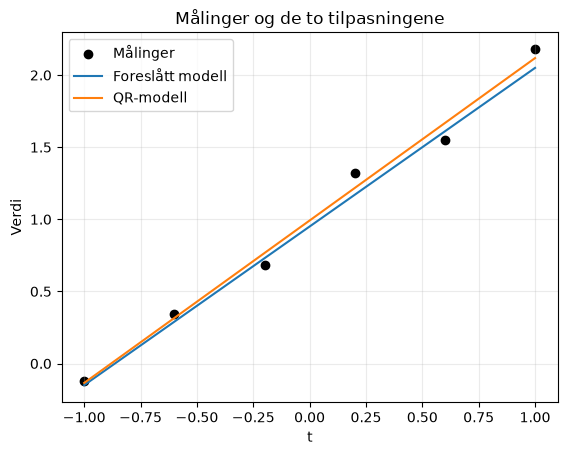

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Data og en foreslått modell. Ingen optimal løsning er beregnet her.
t = np.linspace(-1.0, 1.0, 6)
b = np.array([-0.12, 0.34, 0.68, 1.32, 1.55, 2.18]) #Målinger
c_try = np.array([0.95, 1.10])

# Oppgave 1
A = np.column_stack((np.ones_like(t), t))

residual = b - A @ c_try
kvadratsum = np.sum(residual**2)

print("A: \n", A)
print("Residualer:", residual)
print("Kvadratsum:", kvadratsum)

# Oppgave 2
Q, R = modified_gram_schmidt(A)
c_qr = np.linalg.solve(R, Q.T @ b)

print("\n Oppgave 2")
print("Koeffisienter:", c_qr)

# Oppgave 3

r_qr = b - A @ c_qr
r_try = b - A @ c_try

print("\nOppgave 3")
print("Q^TQ − I:\n", np.linalg.norm(Q.T @ Q - np.eye(2), "fro"))
print("A − QR:\n", np.linalg.norm(A - Q @ R, "fro"))
print("Q^Tr for QR:", Q.T @ r_qr)
print("Q^Tr for den foreslåtte tilpasningen:", Q.T @ r_try)

# Oppgave 4
c_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]

print("\nOppgave 4")
print("lstsq:", c_lstsq)
print("Er c_qr og c_lstsq like:", np.allclose(c_qr, c_lstsq))

plt.scatter(t, b, color="black", label="Målinger")
plt.plot(t, A @ c_try, label="Foreslått modell")
plt.plot(t, A @ c_qr, label="QR-modell")

plt.xlabel("t")
plt.ylabel("Verdi")
plt.title("Målinger og de to tilpasningene")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

#### Oppgave 1
A har dimensjonen $(6 \times 2)$, c har dimensjonen $(2 \times 1)$ og b har dimensjonen $(6 \times 1)$.

A har formen
$$
A = \begin{bmatrix}
1 & -1 \\ 1 & -0.6 \\ 1 & -0.2 \\ 1 & 0.2 \\ 1 & 0.6 \\ 1 & 1
\end{bmatrix}
$$

Residulaen blir da
$$
r = \begin{bmatrix}
0.03 \\  0.05 \\ -0.05 \\ 0.15 \\ -0.06 \\ 0.13
\end{bmatrix}
$$

Kvadratsummen er
$$
0.04890000000000008
$$

Målingene som ligger over den foreslåtte modellen er $-0.12, 0.34, 1.32, 2.18$, dette er lest fra grafen.

#### Oppgave 2
Koeffsientene jeg fikk fra koden ble: $0.99166667 1.12642857$

Koeffesientene jeg fikk får hånd ble: $c_1 \approx 0.99167$ og $c_2 \approx 1.12643$

**Utregning for hånd**

<img src="bilder/oppgave1.2.jpeg" alt="Utregning for hånd" width="400">

#### Oppgave 3

**$Q^TQ-I$**

Dette sjekker om kolonnene i $Q$ har lengde 1 og står vinkelrett på hverandre. Jeg får $Q^TQ-I=2.230969341644725e{-16}\approx0$, så dette stemmer.

**$A-QR$**

Dette sjekker om $Q$ og $R$ bygger opp den opprinnelige matrisen $A$. Jeg får $A-QR=1.5700924586837752e{-16}\approx0$, så QR-faktoriseringen stemmer.

**$Q^Tr$**

Dette sjekker om residualen står vinkelrett på kolonnene i $Q$. For den nye tilpasningen får jeg $Q^Tr_{qr}=\approx0$. For den foreslåtte tilpasningen får jeg derimot

$$
Q^Tr_{\mathrm{try}}\approx
\begin{bmatrix}
0.1021\\
0.0442
\end{bmatrix}.
$$

Den foreslåtte tilpasningen oppfyller derfor ikke denne kontrollen.

#### Oppgave 4
Residualen til QR-modellen er ikke null, som fører til at linjen ikke treffer alle målingene. QR kontrollene er nær null, som viser at beregningen stemmer.

### 2. Finn årsaken når beregningen svikter

Gitt: en ny matrise $B$ og de to GS-funksjonene. **Undersøk:** Kan alle tre kolonnene gi hver sin ortonormale vektor?

Før du kjører koden: Finn en eventuell sammenheng mellom kolonnene, og forutsi hva som skjer med diagonalverdiene i $R$

Kolonne 1 + 2 = kolonne 3. Kolonnene er avhengige

In [20]:
B = np.array([[1.0, 0.0, 1.0],
              [0.0, 1.0, 1.0],
              [0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0]])

# Samme matrise sendes til begge funksjonene.
# En stopp eller en ugyldig verdi skal registreres som et forsøksresultat.
for name, method in [
    ("klassisk GS", classical_gram_schmidt),
    ("modifisert GS", modified_gram_schmidt),
]:
    try:
        with np.errstate(divide="ignore", invalid="ignore"):
            Q_test, R_test = method(B)
        print(name, "diagonal i R:", np.diag(R_test))
        print("alle verdier endelige:", np.isfinite(Q_test).all())
    except np.linalg.LinAlgError as error:
        print(name, "stoppet:", error)


# Oppgave 2
print("\nOppgave 2")
delta = [1.e-4, 1.e-10, 1.e-16]

for i in delta:
    B_kopi = B.copy()
    B_kopi[2, 2] = i
    print("\nDelta verdi: ", i)

    for name, method in [
        ("klassisk GS", classical_gram_schmidt),
        ("modifisert GS", modified_gram_schmidt),
    ]:
        try:
            with np.errstate(divide="ignore", invalid="ignore"):
                Q_test, R_test = method(B_kopi)

            print(name, "diagonal i R:", np.diag(R_test))
            print("alle verdier endelige:", np.isfinite(Q_test).all())
        except np.linalg.LinAlgError as error:
            print(name, "stoppet:", error)

klassisk GS diagonal i R: [1. 1. 0.]
alle verdier endelige: False
modifisert GS stoppet: Kolonne 3 gir ingen pålitelig ny retning

Oppgave 2

Delta verdi:  0.0001
klassisk GS diagonal i R: [1.e+00 1.e+00 1.e-04]
alle verdier endelige: True
modifisert GS diagonal i R: [1.e+00 1.e+00 1.e-04]
alle verdier endelige: True

Delta verdi:  1e-10
klassisk GS diagonal i R: [1.e+00 1.e+00 1.e-10]
alle verdier endelige: True
modifisert GS diagonal i R: [1.e+00 1.e+00 1.e-10]
alle verdier endelige: True

Delta verdi:  1e-16
klassisk GS diagonal i R: [1.e+00 1.e+00 1.e-16]
alle verdier endelige: True
modifisert GS stoppet: Kolonne 3 gir ingen pålitelig ny retning


#### Oppgave 1
Tredje kolonne er summen av de to første kolonnene. Når GS trekker fra kolonnene, blir resten en nullvektor. Divisisjonen $q_3=\frac{v_3}{|v_3|}$ blir det divisisjon med null. Det vil gi et ugyldig svar og funksjonen stopper.

#### Oppgave 2
For $\delta = 10e-4$ får vi:
$$
\text{Klassisk GS} = \begin{bmatrix}1 & 1 & 1.e-04\end{bmatrix}
$$
$$
\text{Modifisert GS} = \begin{bmatrix}1 & 1 & 1.e-04\end{bmatrix}
$$

For $\delta = 10e-10$ får vi:
$$
\text{Klassisk GS} = \begin{bmatrix}1 & 1 & 1.e-10\end{bmatrix} \newline
$$
$$
\text{Modifisert GS} = \begin{bmatrix}1 & 1 & 1.e-10\end{bmatrix}
$$

For $\delta = 10e-16$ får vi:
$$
\text{Klassisk GS} = \begin{bmatrix}1 & 1 & 1.e-16\end{bmatrix}
$$
$$
\text{Modifisert GS = Kolonne 3 gir ingen pålitelig ny retning}
$$

For alle tre verdiene $delta=10^{-4},10^{-10},10^{-16}$ er kolonnene lineært uavhengige i eksakt regning, fordi $delta\neq0$. De to første metodene fullfører, mens for den siste så fullfører klassisk GS med endelige verdier, mens modifisert GS stopper. Dette skyldes at lengden på resten er mindre enn toleransegrensen i funksjonen. Tallet blir ikke avrundet til null og stoppkontrollen vurderer resten som for liten til å normaliseres pålitelig.

#### Oppgave 3
Den modifiserte funksjonen har en stoppkontroll som den klassiske mangler, og det er denne sjekken
```
if R[j, j] <= tolerance:
```
Den hindrer GS i å dele på null eller et svært lite tall; toleransen i tilfellet for B, der delta er $10e{-16}$, er $1.2560739669470201e-15$. Den lengden til $||v_3||$: hvis lengden er stor nok, deler den og fortsetter, men hvis den er under grensen, stopper den og gir en feilmelding.

#### Oppgave 4
Påstanden om at "Alle verdiene i Q er endelige, derfor er QR-faktoriseringen pålitelig" er feil. D
ette kna motbevises med å bruke et eksempel som dette og regne ut:

bruker variablen a, som er $a>0$ og $a\neq1$

$$
B = \begin{bmatrix}
1 & 0 \\ 0 & 1
\end{bmatrix},
\quad
Q = \begin{bmatrix}
a & 0 \\ 0 & 1
\end{bmatrix},
\quad
R = \begin{bmatrix}
1/a & 0 \\ 0 & 1
\end{bmatrix}
$$

Alle verdiene er endelige. Når jeg regner ut $QR$, får jeg

$$
QR = \begin{bmatrix}
a\cdot(1/a) & 0 \\ 0 & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 \\ 0 & 1
\end{bmatrix}
= B
$$

Dette betyr at $B-QR=0$. Men den andre kontrollen gir

$$
Q^TQ-I =
\begin{bmatrix}
a^2 & 0 \\ 0 & 1
\end{bmatrix}
-
\begin{bmatrix}
1 & 0 \\ 0 & 1
\end{bmatrix}
=
\begin{bmatrix}
a^2-1 & 0 \\ 0 & 0
\end{bmatrix}
\neq 0
$$
Siden a er større en 0 og ikke lik 1, blir ikke $a^2-1$ lik null. Dette motbeviser påstanden, og det er ikke nok å bare skjekke om tallene er endeleige.

### 3. Undersøk hva flere målinger bidrar med

Første rad [ 1. -1.  1. -1.]
Residual norm:  7.611305586242616e-16
Største feil:  4.440892098500626e-16
Q^TQ − I: 5.772522278099488e-16
C − QR: 3.152427400121712e-16


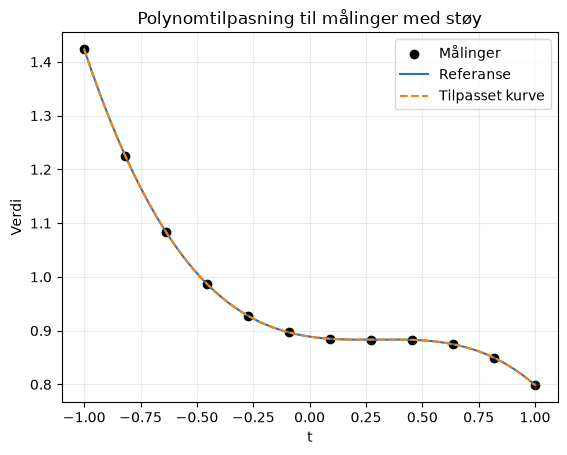

In [18]:
from numpy.polynomial import chebyshev as cheb

# inspiserte siden og fant funksjonen
def reference_coordinates(n):
    k = np.arange(n + 1)
    return (-1.0)**k / (k + 1)**2

def chebyshev_matrix(points, n):
    return cheb.chebvander(np.asarray(points, dtype=float), n)

# Endre én forsøksinnstilling om gangen.
n = 3
m = 12
noise_size = 0
seed = 2026
points = np.linspace(-1.0, 1.0, m)

# Referansen brukes til kontroll; ikke bruk koeffisientene i tilpasningen.
true_coordinates = reference_coordinates(n)
exact_values = cheb.chebval(points, true_coordinates)
rng = np.random.default_rng(seed)
measurements = exact_values + noise_size*rng.standard_normal(m)

# Et tett rutenett gjør det mulig å kontrollere også mellom målepunktene.
grid = np.linspace(-1.0, 1.0, 1001)
reference_curve = cheb.chebval(grid, true_coordinates)

# Oppgave 1
C = chebyshev_matrix(points, n)
print("Første rad", C[0])

# Oppgave 2
c_fit, Q, R = qr_solution(C, measurements)

model_values = cheb.chebval(points, c_fit)
residual_norm = np.linalg.norm(measurements - model_values)

fitted_curve = cheb.chebval(grid, c_fit)
storste_feil = np.max(np.abs(fitted_curve - reference_curve))

# Kontroll tallene
print("Residual norm: ", residual_norm)
print("Største feil: ", storste_feil)
print("Q^TQ − I:",
      np.linalg.norm(Q.T @ Q - np.eye(n + 1), "fro"))
print("C − QR:",
      np.linalg.norm(C - Q @ R, "fro"))

# Plot av referanse og tilpasset kurve
plt.scatter(points, measurements, color="black", label="Målinger")
plt.plot(grid, reference_curve, label="Referanse")
plt.plot(grid, fitted_curve, linestyle="--", label="Tilpasset kurve")

plt.xlabel("t")
plt.ylabel("Verdi")
plt.title("Polynomtilpasning til målinger med støy")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

#### Oppgave 1
Vi har m = 12 målepunkter og et polynom med grad n = 3. Polynomet er:
$$
p(t)=c_0T_0(t)+c_1T_1(t)+c_2T_2(t)+c_3T_3(t)
$$
Siden hvert målepunkt gir en likining så får vi 12 likninger og 4 ukjente. Dermed vil matricen C få dimmensjonene $(12 \times 4)$.

Første rad for C blir da:

<img src="bilder/3.1.jpeg" alt="Utregning for hånd" width="400">

Dette stemmer med koden som også ga:
```
Første rad [ 1. -1.  1. -1.]
```

#### Oppgave 2
Residual normen er $\approx 0.002536$, og den største absloutt forskjellen er $\approx 0.000839$.

Begge størrelsene må undersøkes siden en model kan passe godt til målinger med støy, men avvike fra referanskurven som er uten støy.

#### Oppgave 3
For støy lik $0$:
```
Residual norm:  7.611305586242616e-16
Største feil:  4.440892098500626e-16
Q^TQ − I: 5.772522278099488e-16
C − QR: 3.152427400121712e-16
```

For støy lik $10^{-3}$:
```
Residual norm:  0.0025364461890976754
Største feil:  0.0008394590978575422
Q^TQ − I: 5.772522278099488e-16
C − QR: 3.152427400121712e-16
```

For støy lik $10^{-2}$:
```
Residual norm:  0.02536446189097696
Største feil:  0.008394590978580085
Q^TQ − I: 5.772522278099488e-16
C − QR: 3.152427400121712e-16
```
Uten støy er residualnormen og kurvefeilen nær null. De små avvikene skyldes nok avrunding i flyttallsberegningene.

Når støyen øker, øker også residualnormen og den største feilen. Tilpasningen får derfor større avvik fra målingene og referansekurven.

Kontrollene $Q^TQ-I$ og $C-QR$ er uendret, fordi matrisen $C$ er den samme i alle forsøkene. Støyen endrer bare målingene, ikke målepunktene eller graden.

#### Oppgave 4

In [7]:
import pandas as pd

# Oppgave 4
n = 3
noise_size = 1e-3
m_values = [8, 16, 32]
seeds = [2026, 2027, 2028]

grid = np.linspace(-1.0, 1.0, 1001)
true_coordinates = reference_coordinates(n)
reference_curve = cheb.chebval(grid, true_coordinates)

results = []

for seed in seeds:
    for m in m_values:
        points = np.linspace(-1.0, 1.0, m)
        exact_values = cheb.chebval(points, true_coordinates)

        rng = np.random.default_rng(seed)
        measurements = (
            exact_values + noise_size * rng.standard_normal(m)
        )

        C = chebyshev_matrix(points, n)
        c_fit, Q, R = qr_solution(C, measurements)

        residual = measurements - C @ c_fit
        residualnorm = np.linalg.norm(residual)
        rmse = np.sqrt(np.mean(residual**2))

        fitted_curve = cheb.chebval(grid, c_fit)
        storste_feil = np.max(
            np.abs(fitted_curve - reference_curve)
        )

        results.append({
            "Frø": seed,
            "Antall målinger": m,
            "Residualnorm": residualnorm,
            "RMSE": rmse,
            "Største feil": storste_feil
        })

tabell = pd.DataFrame(results)
print(tabell.to_string(index=False))

 Frø  Antall målinger  Residualnorm     RMSE  Største feil
2026                8      0.002462 0.000870      0.000798
2026               16      0.002703 0.000676      0.000582
2026               32      0.004640 0.000820      0.000394
2027                8      0.002243 0.000793      0.000919
2027               16      0.003186 0.000797      0.000563
2027               32      0.005191 0.000918      0.000947
2028                8      0.002278 0.000805      0.001243
2028               16      0.004291 0.001073      0.000385
2028               32      0.006526 0.001154      0.000466


Konklusjonen er ikke den samme i alle forsøkene.
Frø 2026:
- Kurvefeilen synker fra $0.000798$ til $0.000394$ når antallet målinger øker.
Frø 2027:
- Kurvefeilen synker ved 16 målinger, men øker ved 32 og blir litt større enn ved 8.
Frø 2028:
- Kurvefeilen er lavest ved 16 målinger, men øker litt ved 32.

Det flere målinger vi har så betyr det ikke at kurvefeilen blir mindre. Ved frø 2026 så stemmte det men ikke ved frø 2027 eller 2028. RMSE synker heller ikke jevnt når antall målinger øker.

### 4. Samme målinger, to forskjellige basiser

Gitt: ett polynomrom, ett sett punkter og én målevektor. Undersøk: Har basisvalget betydning for den beregnede kurven?

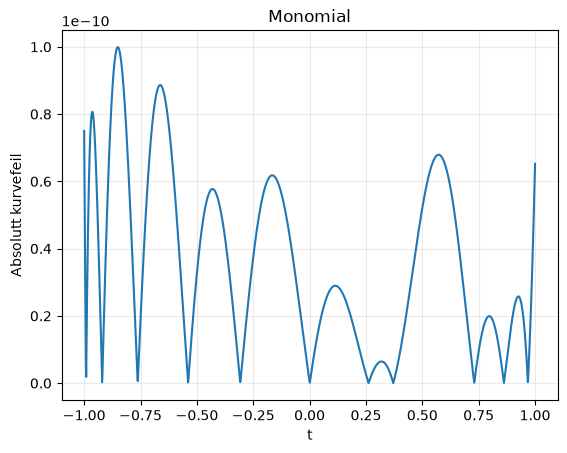

Residualnorm: 2.563158104513898e-10
Ortogonalitetsfeil: 6.170152844473097e-13
Relativ faktoriseringsfeil: 9.110880905581938e-17


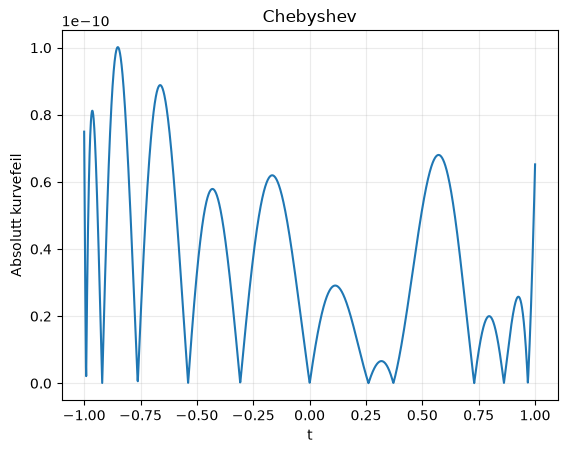

Residualnorm: 2.5631441236661974e-10
Ortogonalitetsfeil: 9.077089046861116e-16
Relativ faktoriseringsfeil: 1.189540567215597e-16


In [8]:
from numpy.polynomial import polynomial as poly

def monomial_matrix(points, n):
    points = np.asarray(points, dtype=float)
    powers = np.arange(n + 1)
    return points[:, None]**powers[None, :]

# Begge basiser skal få nøyaktig de samme dataene.
n = 12
m = 25
points = np.linspace(-1.0, 1.0, m)
true_chebyshev = reference_coordinates(n)
exact_values = cheb.chebval(points, true_chebyshev)
rng = np.random.default_rng(2026)
noise = 1e-10*rng.standard_normal(m)
b_noisy = exact_values + noise

M = monomial_matrix(points, n)
C = chebyshev_matrix(points, n)
grid = np.linspace(-1.0, 1.0, 2001)
reference = cheb.chebval(grid, true_chebyshev)

for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
    # Tilpass med GS
    c, Q, R = qr_solution(A, b_noisy)

    # Lag kurven og beregn abs feil
    kurve = evaluer(grid, c)
    kurvefeil = np.abs(kurve - reference)

    # kontrolltallene
    residualnorm = np.linalg.norm(b_noisy - A @ c)
    ortogonalitetsfeil = np.linalg.norm(
        Q.T @ Q - np.eye(A.shape[1]), "fro"
    )
    faktoriseringsfeil = (
        np.linalg.norm(A - Q @ R, "fro")
        / np.linalg.norm(A, "fro")
    )

    # Plot og print
    plt.figure()
    plt.plot(grid, kurvefeil)
    plt.xlabel("t")
    plt.ylabel("Absolutt kurvefeil")
    plt.title(navn)
    plt.grid(alpha=0.25)
    plt.show()

    print("Residualnorm:", residualnorm)
    print("Ortogonalitetsfeil:", ortogonalitetsfeil)
    print("Relativ faktoriseringsfeil:", faktoriseringsfeil)


#### Oppgave 1
Jeg forventer at de beste modellverdiene ved målepunktetne blir like i eksakt regning. Dette er fordi begge basisene beskriver det samme polynomrommet, og de bruker de samme målingene og punktene.

#### Oppgave 2 og 3


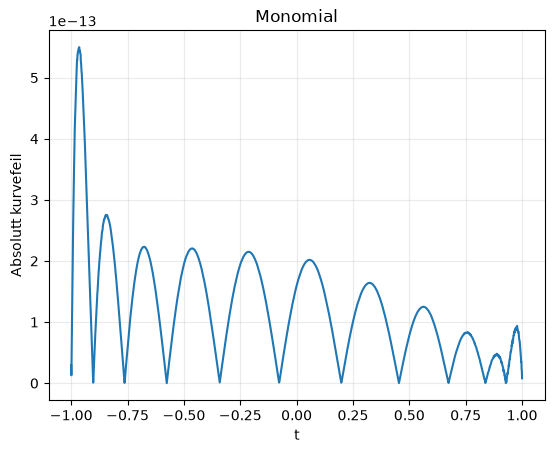

Residualnorm: 6.524766547470003e-13
Ortogonalitetsfeil: 6.170152844473097e-13
Relativ faktoriseringsfeil: 9.110880905581938e-17


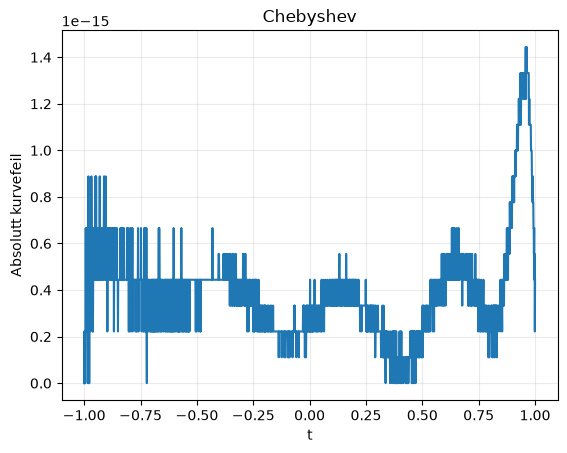

Residualnorm: 2.152802317486082e-15
Ortogonalitetsfeil: 9.077089046861116e-16
Relativ faktoriseringsfeil: 1.189540567215597e-16


In [9]:
for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
    # Tilpass med GS
    c, Q, R = qr_solution(A, exact_values)

    # Lag kurven og beregn abs feil
    kurve = evaluer(grid, c)
    kurvefeil = np.abs(kurve - reference)

    # kontrolltallene
    residualnorm = np.linalg.norm(exact_values - A @ c)
    ortogonalitetsfeil = np.linalg.norm(
        Q.T @ Q - np.eye(A.shape[1]), "fro"
    )
    faktoriseringsfeil = (
        np.linalg.norm(A - Q @ R, "fro")
        / np.linalg.norm(A, "fro")
    )

    # Plot og print
    plt.figure()
    plt.plot(grid, kurvefeil)
    plt.xlabel("t")
    plt.ylabel("Absolutt kurvefeil")
    plt.title(navn)
    plt.grid(alpha=0.25)
    plt.show()

    print("Residualnorm:", residualnorm)
    print("Ortogonalitetsfeil:", ortogonalitetsfeil)
    print("Relativ faktoriseringsfeil:", faktoriseringsfeil)


Grafene viser at begge kurvene kommer nærmere referansekurven når støyen fjernes. Ved å lese av grafen ser jeg at største feil synker fra omtrent $10^{-10}$ til $\approx 5.5\cdot10^{-13}$ for monomial og $\approx 1.4\cdot10^{-15}$ for Chebyshev. Residualnormen avtar for begge basisene, noe som viser at tilpassningen passer bedre uten støy. Ortogonalitetsfeil og relativ faktoriseringsfeil forblir uendret, fordi matrisen fortsatt er den samme.

#### Oppgave 4

In [10]:
for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
    c_lstsq = np.linalg.lstsq(A, b_noisy, rcond=None)[0]
    c_qr, _, _ = qr_solution(A, b_noisy)

    kurve_lstsq = evaluer(grid, c_lstsq)
    kurve_qr = evaluer(grid, c_qr)

    print(f"\n{navn}")
    print("Residualnorm lstsq:",
          np.linalg.norm(b_noisy - A @ c_lstsq))
    print("Største kurvefeil lstsq:",
          np.max(np.abs(kurve_lstsq - reference)))
    print("Største kurvefeil QR:",
          np.max(np.abs(kurve_qr - reference)))


Monomial
Residualnorm lstsq: 2.5631482841113165e-10
Største kurvefeil lstsq: 1.001783100917919e-10
Største kurvefeil QR: 9.990697158457351e-11

Chebyshev
Residualnorm lstsq: 2.5631465824372453e-10
Største kurvefeil lstsq: 1.0017897622560668e-10
Største kurvefeil QR: 1.0017786600258205e-10


`lstsq` gir omtrent samme residualnorm, $2.56\cdot10^{-10}$, for begge basisene. Den største kurvefeilen er rundt $10^{-10}$ for både lstsq og modifisert GS. Basisvalg og beregningsmetode gir derfor små forskjeller i dette forsøket. I oppgave 4.3 ble kurvefeilen mye mindre da støyen ble fjernet. Dette viser at støyen i måledataene har større betydning enn valg av basis og metode her.

## Fordypning

### 5. Når betyr GS-varianeten noe?


Monomial
 Grad        Metode  Residualnorm  Ortogonalitetsfeil  Relativ faktoriseringsfeil  Modellforskjell  Kurvefeil GS  Kurvefeil lstsq
    8   klassisk GS     2.565e-10           6.493e-13                   6.698e-17        2.887e-14     6.943e-11        6.945e-11
   12   klassisk GS     2.821e-10           4.219e-09                   7.983e-17        5.229e-11     1.876e-10        2.384e-10
   16   klassisk GS     1.545e-06           1.631e-04                   7.326e-17        7.467e-07     2.081e-06        2.505e-10
   20   klassisk GS     7.163e-03           1.454e+00                   7.649e-17        1.952e-03     1.246e-02        6.362e-10
    8 modifisert GS     2.565e-10           3.428e-14                   6.500e-17        2.731e-14     6.942e-11        6.945e-11
   12 modifisert GS     2.641e-10           4.063e-13                   7.439e-17        3.586e-13     2.380e-10        2.384e-10
   16 modifisert GS     3.639e-10           1.917e-11                   7.346e-1

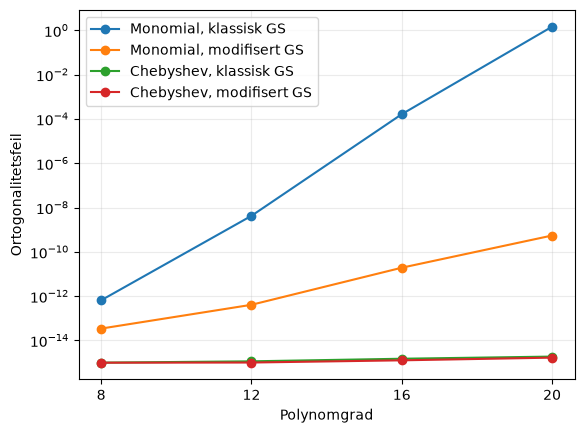

In [11]:

degrees = [8, 12, 16, 20]
methods = [
    ("klassisk GS", classical_gram_schmidt),
    ("modifisert GS", modified_gram_schmidt),
]
results = []

for method_name, method in methods:
    for n in degrees:
        m = 2*(n+1)+1
        noise_size = 1e-10
        seed = 2026

        # Nye målepunkter og referanse for hver grad
        points = np.linspace(-1, 1, m)
        true_coordinates = reference_coordinates(n)
        exact_values = cheb.chebval(points, true_coordinates)
        reference_curve = cheb.chebval(grid, true_coordinates)

        # Målinger med støy og fast seed
        rng = np.random.default_rng(seed)
        b_noisy = exact_values + noise_size * rng.standard_normal(m)

        # Matriser
        M = monomial_matrix(points, n)
        C = chebyshev_matrix(points, n)

        for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
            # Hvis beregningen stopper, skriv ut feil og gå videre
            try:
                c, Q, R = qr_solution(A, b_noisy, qr_method=method)
            except np.linalg.LinAlgError as error:
                print(n, navn, method_name, "stoppet:", error)
                continue

            # Kontrolltall
            residualnorm = np.linalg.norm(b_noisy - A @ c)

            ortogonalitetsfeil = np.linalg.norm(
                Q.T @ Q - np.eye(n + 1), "fro"
            )

            faktoriseringsfeil = (
                np.linalg.norm(A - Q @ R, "fro")
                / np.linalg.norm(A, "fro")
            )

            # Sammenlign med lstsq
            c_lstsq = np.linalg.lstsq(A, b_noisy, rcond=None)[0]

            modell_forskjell = np.max(np.abs(A @ c - A @ c_lstsq))

            # Kurve feil mot ref, og målepunktene
            kurve = evaluer(grid, c)
            kurve_lstsq = evaluer(grid, c_lstsq)

            kurvefeil = np.max(np.abs(kurve - reference_curve))
            kurvefeil_lstsq = np.max(np.abs(kurve_lstsq - reference_curve))

            # Skjekker tall verdiene om de er NaN eller uendelige
            tall = [
                residualnorm,
                ortogonalitetsfeil,
                faktoriseringsfeil,
                modell_forskjell,
                kurvefeil,
                kurvefeil_lstsq,
            ]

            if not np.isfinite(tall).all():
                print(n, navn, method_name, " ga ugyldige verdier")
                continue

            # Lagre resultatene
            results.append({
                "Grad": n,
                "Basis": navn,
                "Metode": method_name,
                "Residualnorm": residualnorm,
                "Ortogonalitetsfeil": ortogonalitetsfeil,
                "Relativ faktoriseringsfeil": faktoriseringsfeil,
                "Modellforskjell": modell_forskjell,
                "Kurvefeil GS": kurvefeil,
                "Kurvefeil lstsq": kurvefeil_lstsq,
            })

tabell = pd.DataFrame(results)

# Ryddigere tabell utskrift
for navn in ["Monomial", "Chebyshev"]:
    print(f"\n{navn}")
    utvalg = tabell[tabell["Basis"] == navn].drop(columns="Basis")
    print(utvalg.to_string(
        index=False,
        float_format=lambda x: f"{x:.3e}"
    ))

# Plott av ortogonalitetsfeil mot grad
plt.figure()

for navn in ["Monomial", "Chebyshev"]:
    for method_name, method in methods:
        utvalg = tabell[
            (tabell["Basis"] == navn)
            & (tabell["Metode"] == method_name)
        ]

        plt.semilogy(
            utvalg["Grad"],
            utvalg["Ortogonalitetsfeil"],
            marker="o",
            label=f"{navn}, {method_name}"
        )

plt.xlabel("Polynomgrad")
plt.ylabel("Ortogonalitetsfeil")
plt.xticks(degrees)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Jeg valgte å undersøke spørsmålet "Er en liten faktoriseringsfeil tilstrekkelig til å stole på Q?" nærmere. Jeg brukte klassiskk GS i monomialbasisen ved grad 20 under undersøklsen.

| Grad | Metode | Residualnorm | Ortogonalitetsfeil | Relativ faktoriseringsfeil | Modellforskjell | Kurvefeil GS | Kurvefeil lstsq |
|---|---|---|---|---|---|---|---|
| 20 | Klassisk GS | 7.163e-03 | 1.454e+00 | 7.649e-17 | 1.952e-03 | 1.246e-02 | 6.362e-10 |

Den relative faktoriseringsfeilen er $7.649e-17$, som betyr at produktet av $QR$ er nær den opprinelige matrisen $A$. Samtidig er ortogonalitetsfeilen $1.454$, som viser at $Q^TQ$ ikke er nærme identitetsmatrisen. Selv om $QR\approx A$ er kolonne i Q ikke tilstrekkelig ortonormale. Dette svekker beregningen av tilpasningen, som bruker $Rc=Q^Tb$.

Vi ser forskjellen tydlig i kurvefeilen, hvor klassisk GS gir $1.246e-2$, mens `lstsq` gir $6.362e-10$ på smme matrise og målinger.

Forsøket viser at en liten faktoriseringsfeil ikke er nok til å stole på tilpasningen. Vi må også undersøke ortogonaliteten til $Q$ og hvor nøyaktid den bergende kurven er.

### 7. Gjør en begrunnet forbedring

In [22]:
n = 20
m = 2 * (n + 1) + 1

# Målepunkter og kontrollpunkter
points = np.linspace(-1, 1, m)
grid = np.linspace(-1, 1, 2001)

# Samme referanse for begge metodene
true_coordinates = reference_coordinates(n)
exact_values = cheb.chebval(points, true_coordinates)
reference_curve = cheb.chebval(grid, true_coordinates)

# Målinger med støy og fast seed
rng = np.random.default_rng(2026)
b_noisy = exact_values + 1e-10 * rng.standard_normal(m)

# Monomialmatrise
M = monomial_matrix(points, n)

results = []

# Bytter metode, resten holdes likt
for navn, method in [
    ("Før: klassisk GS", classical_gram_schmidt),
    ("Etter: modifisert GS", modified_gram_schmidt),
]:
    # Tilpass med GS
    c, Q, R = qr_solution(M, b_noisy, qr_method=method)

    # Residual og tilpasset kurve
    residual = b_noisy - M @ c
    kurve = poly.polyval(grid, c)

    # Beregn kontroltall og lagre resultatene
    results.append({
        "Metode": navn,
        "Residualnorm": np.linalg.norm(residual),
        "RMSE": np.sqrt(np.mean(residual**2)),
        "Største kurvefeil": np.max(
            np.abs(kurve - reference_curve)
        ),
        "Ortogonalitetsfeil": np.linalg.norm(
            Q.T @ Q - np.eye(n + 1), "fro"
        ),
        "Relativ faktoriseringsfeil": (
            np.linalg.norm(M - Q @ R, "fro")
            / np.linalg.norm(M, "fro")
        ),
    })

# Ryddigere tabellutskrift
tabell = pd.DataFrame(results)
print(tabell.to_string(
    index=False,
    float_format=lambda x: f"{x:.3e}"
))

              Metode  Residualnorm      RMSE  Største kurvefeil  Ortogonalitetsfeil  Relativ faktoriseringsfeil
    Før: klassisk GS     7.163e-03 1.092e-03          1.246e-02           1.454e+00                   7.649e-17
Etter: modifisert GS     5.339e-10 8.143e-11          9.069e-10           5.444e-10                   1.035e-16


Residualnormen sank fra $7.163e{-3}$ til $5.339e^{-10}$, og RMSE sank fra $1.092e{-3}$ til $8.143e{-11}$. Den største kurvefeilen sank også fra $1.246e{-2}$ til $9.069e{-10}$. Tilpasningen kommer derfor mye nærmere både målingene og referansekurven. Ortogonalitetsfeilen sank også fra $1454$ til $5.44e{-10}$, som viser at kollonen i $Q$ ble nærmere ortonormale. Del relative faktoriseringsfeilen steg fra $5.649e{-17}$ til ${1.035e{-16}, men verdien er svært liten.

Modfisert GS ga en tydlig forbedring. Resultatene viser også at en liten faktorisingsfeil alene ikke er nok til å vurdere om tilpasningen er pålitelig.